In [1]:
import json
with open('./out/EC_hypergraph.json', 'r') as myfile:
    hypergraph_emp=json.load(myfile)



# Watts model

Extention of the dynamic version of the connection model to hypergraphs.
In the original model:
$$u_i(g) = \sum_{j \neq i} \delta^{t(ij)} - \sum_{j: ij \in g} c$$
agent i receives a payoff of  $0<\delta <1$ for each direct link, and pays a cost of $1 >c>0$ of maintaining each direct link she has. Agent i can also be indirectly connected to agent $j \neq i$  .Let $t(ij)$ represent the number of direct links in the shortest path between agents i and j. Then $\delta ^{t(ij)}$ is the payoff agent $i$ receives from being indirectly connected to agent $j$, where we adopt the convention that if there is no path between $i$ and $j$, then $ \delta^{t(ij)}=0$. 
Then edge $ij$ is added if both agents $i$ and $j$ benefit from this link.

In [2]:
import numpy as np
import random
import matplotlib.pyplot as plt
import multiprocessing as mp
from tqdm import tqdm
from collections import Counter
import xgi
def utility(i, H: xgi.hypergraph):
    t_ij = xgi.algorithms.shortest_path.single_source_shortest_path_length(H,i)
    return sum([ delta ** t_ij[k] for k in H.nodes if t_ij[k] < np.inf and k!=i ]) -c* H.degree(i)

delta = 0.9
c = 0.1
n = 10
players = list(range(n))
edges = [[1,2]]
H = xgi.Hypergraph()
H.add_nodes_from(players)
for i in players:
    for j in players:
        H_ij = H.copy()
        H_ij.add_edge([i,j])
        if utility(i, H_ij) > utility(i, H) and utility(j, H_ij) > utility(j, H):
            H.add_edge([i,j])
H.edges.members()

[{0, 1}, {0, 2}, {0, 3}, {0, 4}, {0, 5}, {0, 6}, {0, 7}, {0, 8}, {0, 9}]

# Jun Model
In the original paper

$$u_i(H)=  1 + deg(i) +\sum_{j \notin E_i} \delta^{t(i,j)} - \sum_{e \in E_i} \frac{c_0 + c|e|}{|e|} $$
for c and c_0 high enough, the grand hypergraph and the empty hypergraph are stable.
for c and c_0 low enough, the star hypergraph is stable.


In [ ]:
def utility(i,o,H: xgi.Hypergraph):
    t_ij = xgi.algorithms.shortest_path.single_source_shortest_path_length(H,i)
    E_i = H.nodes.memberships(i)
    benefit =  sum([ delta ** t_ij[k] for k in H.nodes if t_ij[k] < np.inf and k not in ( H.nodes.neighbors(i) | {i} )]) +1 + H.degree(i)
    cost = sum( [ (c_0 + c * H.edges.size.asdict()[e] )/ H.edges.size.asdict()[e] for e in E_i])
    #print(i,f'benefits: {benefit}, costs:{ cost}, utility : {benefit - cost}')
    return benefit - cost
# # star network
# delta = 0.5
# c = 0.1
# c_0 = 0.2
# grand hypergraph
# delta = 0.9
# c = 0.7
# c_0 = 0.7

delta = 0.7
c = 0.6
c_0 = 0.7

n = 20
M = 30
players = list(range(n))
H = xgi.Hypergraph()
H.add_nodes_from(players)
hyperedges = []
count = 0
m = 0

while m < M:
    count +=1
    # Add edge
    d = random.randint(1,len(H.nodes))
    e = np.random.choice(H.nodes, d, replace = False )
    H_ie = H.copy()
    H_ie.add_edge(e)
    for i in e:
        accepted = True
        if utility(i, o, H_ie) < utility(i,o, H):
            accepted = False
            break
    if accepted:
        H.add_edge(e)
        hyperedges.append(e[:])
        m += 1
    # Remove edge
    if H.num_edges > 0:
        e_del = np.random.choice(list(H.edges))
        for j in list(H.edges.members(e_del)):
            H_not_j_e = H.copy()
            H_not_j_e.remove_edge(e_del)
            if utility(j, o, H_not_j_e) > utility(j,o, H):
                H.remove_edge(e_del)
                break

H.edges.members()

# Strategic hypergraph formation
In this model
    $$u_i(H) = \sum_{j \neq i} \delta^{t(ij)} - c\sum_{e\in E_i} C(e)$$
    $$C(e) = \sum_{j \in e} | o_j - \mu_e |$$
agent i receives a payoff of  $0<\delta <1$ for each direct link, and pays a cost of $ C(e)$ of maintaining each direct link she has. Agent i can also be indirectly connected to agent $j \neq i$  .Let $t(ij)$ represent the number of direct links in the shortest path between agents i and j. Then $\delta ^{t(ij)}$ is the payoff agent $i$ receives from being indirectly connected to agent $j$, where we adopt the convention that if there is no path between $i$ and $j$, then $ \delta^{t(ij)}=0$. 
Then edge $ij$ is added if both agents $i$ and $j$ benefit from this link.

Check multiplicity of edges. Do edges with the same configuration happen several time. Check if the add_edge function from xgi adds an already existing edge.

In [4]:
from IPython.display import clear_output
import numpy as np
import random
import matplotlib.pyplot as plt
import multiprocessing as mp
from tqdm import tqdm
from collections import Counter
import xgi
 

def compute_utility(i, o, H, param, edge_distances, t_i, print_details = False):
    delta, c, _, _, _ = param
    benefit = sum(delta ** t_i[k] for k in H.nodes if k != i and t_i[k] < np.inf) 
    #cost = c * sum(edge_distances.get(e_label,compute_edge_distance(H.edges.members(e_label),o)) for e_label in H.nodes.memberships(i))
    cost = c
    return benefit - cost

def update_utilities(H, o, param, edge_distances):
    utility = dict()
    t = list(xgi.algorithms.shortest_path.shortest_path_length(H))
    t = {key: value for key, value in t}
    for i in H.nodes:
        t_i = t[i]
        utility[i] = compute_utility(i, o, H, param, edge_distances, t_i, print_details = True)
    return utility 
        

def compute_edge_distance(e,o):
    mean_opinion = np.mean([o[node] for node in e])
    return np.sum([abs(o[node] - mean_opinion) for node in e])

def update_edge_distances(edge_distances, e_label, e, o):
    edge_distances.update({e_label:compute_edge_distance(e,o)})
    return(edge_distances)


def strategic_H(param):
    delta, c, n, M, p_new = param
    players = list(range(n))
    H = xgi.Hypergraph()
    H.add_nodes_from(players)
    o = list(np.random.uniform(-1,1,n))
    hyperedges = []
    count = 0
    label_new_node = n
    m = 0
    utility = {i: 0 for i in H.nodes}
    edge_distances = {}
    while m<M:
        count +=1
        # Add edge
        d = random.randint(2,len(H.nodes))
        e = set(np.random.choice(H.nodes, d, replace = False ))
        H_ie = H.copy()
        H_ie.add_edge(e)    
        
        # Check acceptance condition
        for i in e:
            accepted  = True 
            if i not in H_ie.nodes:
                u_i = 0
            else:
                t_i = xgi.algorithms.shortest_path.single_source_shortest_path_length(H_ie,i)
                u_i = compute_utility(i,o,H_ie,param,edge_distances,t_i)
            if u_i< utility.get(i,0):
                accepted = False
                break
            
        if accepted:
            H.add_edge(e)
            hyperedges.append(e)
            edge_distances = update_edge_distances(edge_distances,m,e,o)
            utility = update_utilities(H, o, param, edge_distances)
            m += 1
            #clear_output(wait = True)
                               
        # Remove edge
        if H.num_edges > 0:
            e_del = np.random.choice(list(H.edges))
            for i in list(H.edges.members(e_del)):
                H_not_i_e = H.copy()
                H_not_i_e.remove_edge(e_del)
                if i not in H_not_i_e.nodes:
                    u_i = 0
                else:
                    t_i = xgi.algorithms.shortest_path.single_source_shortest_path_length(H_not_i_e,i)
                    u_i = compute_utility(i,o,H_not_i_e,param,edge_distances,t_i)
                if  u_i > utility.get(i,0):
                    H.remove_edge(e_del)
                    utility = update_utilities(H,o, param, edge_distances)
                    break

        # # Add and remove node
        # utilities = {node: utility[node] for node in H.nodes if utility[node]>0} # utility of connected nodes
        # connected_nodes = list(utilities.keys())
        # n_new = np.random.binomial(len(connected_nodes),0.01)
        # if n_new > 0:
        #     # Remove nodes with the lowest utility
        #     to_remove = sorted(utilities, key=utilities.get)[:n_new]  # Nodes with the lowest utility
        #     new_nodes = list(range(label_new_node, label_new_node + n_new))
        #     label_new_node += n_new
        #     H.add_nodes_from(new_nodes)
        #     H.remove_nodes_from(to_remove, strong=True)  # Remove selected nodes
        #     o += list(np.random.uniform(-1, 1, n_new))
        #     utility = update_utilities(H, o, param, edge_distances)
    print(count)
    return(hyperedges,o)


In [22]:
delta = 0.3
n = 10
M = 100
p_new = 0.3
c = 1
param = delta, c, n, M, p_new
H ,o= strategic_H(param)

101


In [19]:

step = 0.04
cs = np.arange(0.0,0.2 + step,step)
cs = [0.1]
nb_sim = len(cs)

delta = 0.3
n = 30
M = 100
p_new = 0.3
c = 0.6

deltas = [delta]*nb_sim
ns = [n]*nb_sim
Ms = [M]*nb_sim
p_news = [p_new]*nb_sim

nb_itt = 7

param = [(_delta, _c, _n, _M, _p_new) for _delta, _c, _n, _M, _p_new in zip(deltas, cs, ns, Ms, p_news) for i in range(nb_itt)]
pool = mp.Pool()
result = pool.map(strategic_H, param)
pool.close()
hypergraphs = []
opinions = []

for i in range(len(result) // nb_itt):
    # Extract all `hyperedges` for this parameter
    grouped_hyperedges = [result[j][0] for j in range(nb_itt * i, nb_itt * (i + 1))]
    hypergraphs.append(grouped_hyperedges)

    # Extract all `opinions` for this parameter
    grouped_opinions = [result[j][1] for j in range(nb_itt * i, nb_itt * (i + 1))]
    opinions.append(grouped_opinions)


100
100
100
100
100
100
100


## Histrograms

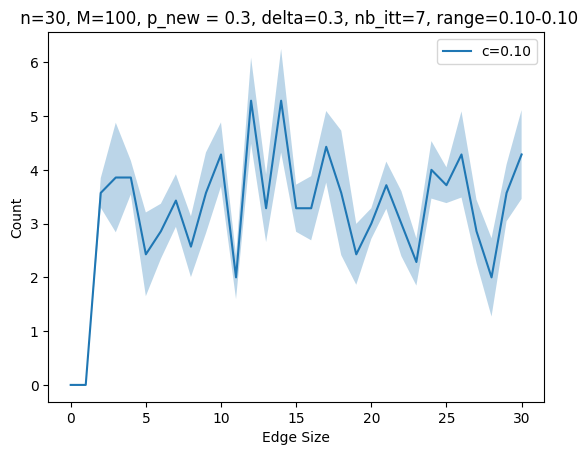

In [20]:
def edge_size_distribution(hypergraph):
    return Counter([len(e) for e in hypergraph]) 
    
def average_distribution(distributions):
    nb_itt = len(distributions)
    # Find the maximum key across all Counters
    max_key = max(max(counter.keys()) for counter in distributions)
    # Initialize a 2D NumPy array of shape (nb_itt,max_key)
    distributions_np = np.zeros((nb_itt, max_key + 1), dtype=int)
    # fill the array
    for i, counter in enumerate(distributions):
        for key, value in counter.items():
            distributions_np[i, key] = value
    # Calculate mean and standard error for edge sizes
    avg_distribution = distributions_np.mean(axis=0)
    stderr_distributions = distributions_np.std(axis=0) / np.sqrt(nb_itt)
    return(avg_distribution, stderr_distributions)
    
for c, hypergraphs_c in zip(cs, hypergraphs):
    # Plotting avarage random
    counters = [ edge_size_distribution(hypergraph) for hypergraph in hypergraphs_c]
    avg_distribution, stderr_distributions = average_distribution(counters)
    #plt.figure(figsize=(10, 6))
    plt.plot(avg_distribution, label=f'c={c:.2f}')
    plt.fill_between(
        range(len(avg_distribution)),
        avg_distribution - stderr_distributions,
        avg_distribution + stderr_distributions,
        #color="blue",
        alpha=0.3,
        #label="Standard error"
    )

# for i , hypergraph in enumerate(hypergraphs):
#     # Plotting one random
#     distribution_rand = edge_size_distribution(hypergraph)
#     max_key = max(distribution_rand.keys())
#     distribution_np = np.zeros(max_key + 1, dtype=int)
#     for key, value in distribution_rand.items():
#         distribution_np[ key] = value
#     plt.plot(distribution_np,  label = f'c={cs[i] :.2f}')

# #Plotting empirical
# hypergraph_emp = [e for e in hypergraph_emp if len(e)>1]
# distribution_emp = edge_size_distribution(hypergraph_emp[:M])
# max_key = max(distribution_emp.keys())
# distribution_np = np.zeros(max_key + 1, dtype=int)
# for key, value in distribution_emp.items():
#     distribution_np[ key] = value
# plt.plot(distribution_np, label = 'Empirical')

plt.xlabel("Edge Size")
plt.ylabel("Count")
plt.legend()
title = f" n={n}, M={M}, p_new = {p_new}, delta={delta}, nb_itt={nb_itt}, range={cs[0]:.2f}-{cs[-1]:.2f}"
plt.title(title)
#plt.savefig(f'./out/param_explo/edge_size_{title}.pdf')
plt.show()


Text(0.5, 1.0, ' n=30, M=100, p_new = 0.3, delta=0.3, nb_itt=7, range=0.10-0.10')

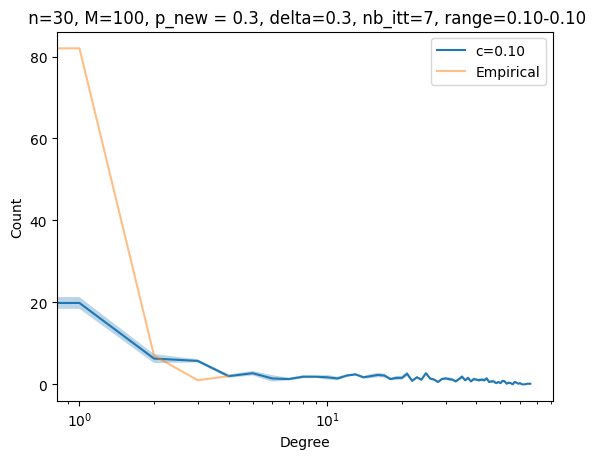

In [24]:
def degree_distribution(hypergraph):
    hypergraph = [list(e) for e in hypergraph]
    return Counter(Counter([ node for node in np.concatenate(hypergraph)]).values())

#Plotting average random
for c, hypergraphs_c in zip(cs, hypergraphs):
    counters = [degree_distribution(hypergraph) for hypergraph in hypergraphs_c]
    avg_distribution, stderr_distributions = average_distribution(counters)
    #plt.figure(figsize=(10, 6))
    plt.plot(avg_distribution, label=f"c={c:.2f}")
    plt.fill_between(
        range(len(avg_distribution)),
        avg_distribution - stderr_distributions,
        avg_distribution + stderr_distributions,
        #color="blue",
        alpha=0.3,
        #label="Standard error"
)
# # Plotting one random
# for c, hypergraphs_c in zip(cs, hypergraphs):
#     distribution_rand = degree_distribution(hypergraph)
#     max_key = max(distribution_rand.keys())
#     distribution_np = np.zeros(max_key + 1, dtype=int)
#     for key, value in distribution_rand.items():
#         distribution_np[ key] = value
#     plt.plot(distribution_np, label =  f'c={cs[i] :.2f}')
#     plt.legend()
#     title = f" n={n}, M={M}, p_new = {p_new}, delta={delta}, c={cs[i] :.2f}"
#     plt.title(title)
#     plt.savefig(f'./out/param_explo/degree_{title}.pdf')
#     plt.xlabel("Degree")
#     plt.ylabel("Count")
#     plt.close()


#Plotting empirical
distribution_emp = degree_distribution(hypergraph_emp[:M])
max_key = max(distribution_emp.keys())
distribution_np = np.zeros(max_key + 1, dtype=int)
for key, value in distribution_emp.items():
    distribution_np[ key] = value
plt.plot(distribution_np, label = 'Empirical', alpha = 0.5)

plt.xscale('log')
plt.xlabel("Degree")
plt.ylabel("Count")
plt.legend()
title = f" n={n}, M={M}, p_new = {p_new}, delta={delta}, nb_itt={nb_itt}, range={cs[0]:.2f}-{cs[-1]:.2f}"
plt.title(title)
#plt.savefig(f'./out/param_explo/degree_{title}.pdf')



## Connectivity

In [ ]:
step = 0.04
#cs = np.arange(0.9,0.9 + step,step)
cs = [1.5]
nb_sim = len(cs)

delta = 0.9
n = 200
M = 30
p_new = 0.3

deltas = [delta]*nb_sim
ns = [n]*nb_sim
Ms = [M]*nb_sim
p_news = [p_new]*nb_sim

nb_itt = 3

param = [(_delta, _c, _n, _M, _p_new) for _delta, _c, _n, _M, _p_new in zip(deltas, cs, ns, Ms, p_news) for i in range(nb_itt)]
pool = mp.Pool()
result = pool.map(strategic_H, param)
pool.close()

# Extract all hyperedges and opinions grouped by values of `param`
hypergraphs = []
opinions = []

for i in range(len(result) // nb_itt):
    # Extract all `hyperedges` for this parameter
    grouped_hyperedges = [result[j][0] for j in range(nb_itt * i, nb_itt * (i + 1))]
    hypergraphs.append(grouped_hyperedges)

    # Extract all `opinions` for this parameter
    grouped_opinions = [result[j][1] for j in range(nb_itt * i, nb_itt * (i + 1))]
    opinions.append(grouped_opinions)


In [ ]:
import joblib
result_  =result.copy()
title =  f'n={n}, M={M}, p_new = {p_new}, delta={delta}, nb_itt={nb_itt}, range={cs[0]:.2f}-{cs[-1]:.2f}'
joblib.dump(result_,'./out/param_explo/result_.joblib')

In [108]:
for c, hypergraphs_c, opinions_c in zip(cs, hypergraphs, opinions):
    for hypergraph, opinion in zip(hypergraphs_c, opinions_c):
        H = xgi.Hypergraph(hypergraph)
        o = opinion
        component_size = [len(component) for component in xgi.connected_components(H)]
        print(component_size)

[512, 2]
[459]
[506, 2]
[538]
[505, 2]
[479]
[469, 2, 2, 2, 2]


Text(0.5, 0, 'opinions')

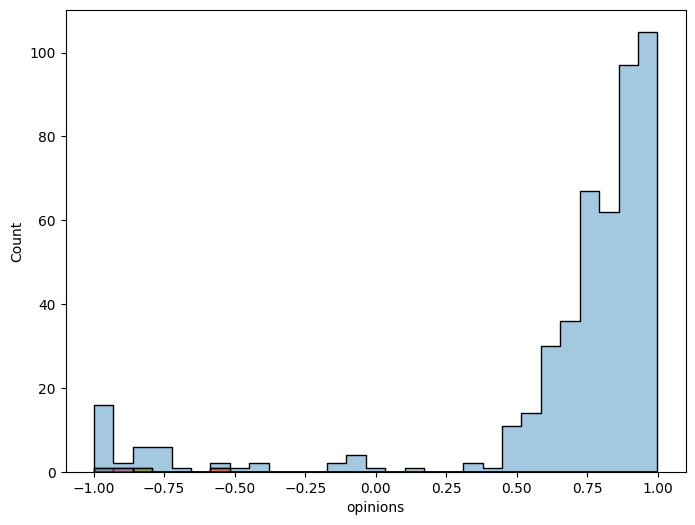

In [113]:
import seaborn as sns
import pandas as pd
idx_c = 0
idx_itt = 6

nodes = list(set(np.concatenate([list(e) for e in hypergraphs[idx_c][idx_itt]])))
H = xgi.Hypergraph(hypergraphs[idx_c][idx_itt])

# Gather opinions from components
plt.figure(figsize=(8, 6))
components = [component for component in xgi.connected_components(H)]
all_opinions = [opinions[idx_c][idx_itt][node] for component in components for node in component if len(component) > 4]

# Determine common bins
min_opinion = min(all_opinions)
max_opinion = max(all_opinions)
bins = np.linspace(min_opinion, max_opinion, 30)  # Adjust number of bins as needed

# Plot histograms for each component
for i, component in enumerate(components):
    component_opinions = [opinions[idx_c][idx_itt][node] for node in component if len(component) > 0]
    if component_opinions:
        sns.histplot(component_opinions, bins = bins, edgecolor = 'k',label=f'component {i}',  alpha =0.4, element = 'step')

#plt.legend()

title = f" n={n}, M={M}, p_new = {p_new}, delta={delta}, nb_itt={nb_itt}, range c ={cs[0]:.2f}-{cs[-1]:.2f}"
#plt.title(title)
plt.xlabel('opinions')
#plt.savefig(f'./out/param_explo/opinion_components_{title}.pdf')

In [114]:
from utils.centrality import XGI_2_nxBipartite
import networkx as nx

import networkx as nx

def convert_to_bipartite_with_opinions(H, opinions, step = 10):
    B = nx.Graph()
    
    # Create unique labels for hyperedges
    hyperedge_offset = max(H.nodes) + 1
    hyperedge_labels = {edge: edge + hyperedge_offset for edge in H.edges}
    
    # Add nodes and hyperedges to the bipartite graph
    B.add_nodes_from(H.nodes, bipartite='entity')
    B.add_nodes_from(hyperedge_labels.values(), bipartite='meeting')
    
    # Add edges between nodes and their hyperedges
    for node in H.nodes:
        for edge in H.nodes.memberships(node):
            B.add_edge(node, hyperedge_labels[edge])
    
    # Add opinions as attributes to entity nodes
    for node, opinion in zip(H.nodes, opinions):
        B.nodes[node]['opinion'] = opinion

    # Add time attributes to hyperedges with dynamic intervals
    for idx, edge in enumerate(H.edges):
        hyperedge_node = hyperedge_labels[edge]
        start_time = idx * step  # Starting time for the edge
        end_time = start_time + step  # Ending time for the edge
        B.nodes[hyperedge_node]['start'] = start_time
        B.nodes[hyperedge_node]['end'] = end_time
    
    return B

B = convert_to_bipartite_with_opinions(H,opinion )

nx.write_gexf(B, "./out/H_strategic_.gexf")